In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as snc

In [2]:
import warnings
warnings.filterwarnings('ignore')

Рассмотрим общие характеристики в представленном датасете, чтобы понять, как нам предстоит работать в дальнейшем над задачей.

In [3]:
t_games = pd.read_csv('./datasets/T_games_dataset.csv')
t_games.describe()

,id,category_id,good_id,good_price,good_cnt,age,monthly_income_amt,steam_popularity_score
count,8.869900e+04,88699.000000,8.869900e+04,88699.000000,88699.0,88699.000000,8.869900e+04,88699.000000
mean,1.500462e+09,28968.248932,1.135675e+06,584.402189,1.0,26.600187,9.026706e+04,475.555395
std,1.448781e+05,1061.080699,2.831782e+05,877.856786,0.0,8.312742,1.422906e+05,1008.816453
min,1.500208e+09,28555.000000,8.472910e+05,2.320000,1.0,1.000000,-5.246740e+05,0.000000
25%,1.500337e+09,28562.000000,8.488950e+05,119.200000,1.0,20.000000,2.600000e+04,0.000000
50%,1.500457e+09,28574.000000,1.123866e+06,329.000000,1.0,26.000000,6.800000e+04,0.000000
75%,1.500578e+09,28577.000000,1.395053e+06,679.000000,1.0,32.000000,1.381100e+05,282.000000
max,1.500750e+09,35255.000000,1.774802e+06,10656.300000,1.0,86.000000,7.190000e+06,4981.000000


In [4]:
t_games.head(3)

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0


Я заметил в таблице, что самый низкий возраст покупателя был 1 год. Это кажется аномальным значением, поэтому я решил посмотреть количество покупателей меньше 8 лет. Увидел, что их маленькое количество и пришел к выводу, что их можно не рассматривать.

In [5]:
t_games[t_games['age'] < 8]['age'].count()

np.int64(22)

In [6]:
t_games = t_games[t_games['age'] >= 8]
t_games.duplicated().sum()

np.int64(0)

In [7]:
len(t_games['client_id'].unique())

41284

Для более удобной работы в дальнейшем анализе, сделаем предобработку данных. Столбец **order_day** преобразуем в формат **datetime**, чтобы в последующем извлечь такие компоненты, как **год, месяц, день недели**. Создадим новый столбец, для рассчета общей суммы заказа. 

In [8]:
t_games['order_day'] = pd.to_datetime(t_games['order_day'])

t_games['order_sum'] = t_games['good_price'] * t_games['good_cnt']
t_games['year'] = t_games['order_day'].dt.year
t_games['month'] = t_games['order_day'].dt.month
t_games['weekday'] = t_games['order_day'].dt.weekday

total_orders = t_games.groupby(by='id')['order_sum'].sum().reset_index()
total_orders = total_orders.rename(columns={'order_sum': 'total_orders_sum'})

t_games = t_games.merge(total_orders, on='id', how='left')

In [9]:
t_games.head(3)

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,order_sum,year,month,weekday,total_orders_sum
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0,299.00,2023,5,0,299.00
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0,269.85,2023,5,0,269.85
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0,77.00,2023,5,2,77.00


Визуализируем зависимоть числа продаж, от цены. Также число продаж, от временного промежутка.(Предполагаю, что спрос на товар повыщается в зависимости от временного промежутка.)

Text(0.5, 1.0, 'Распределение цен на игры')

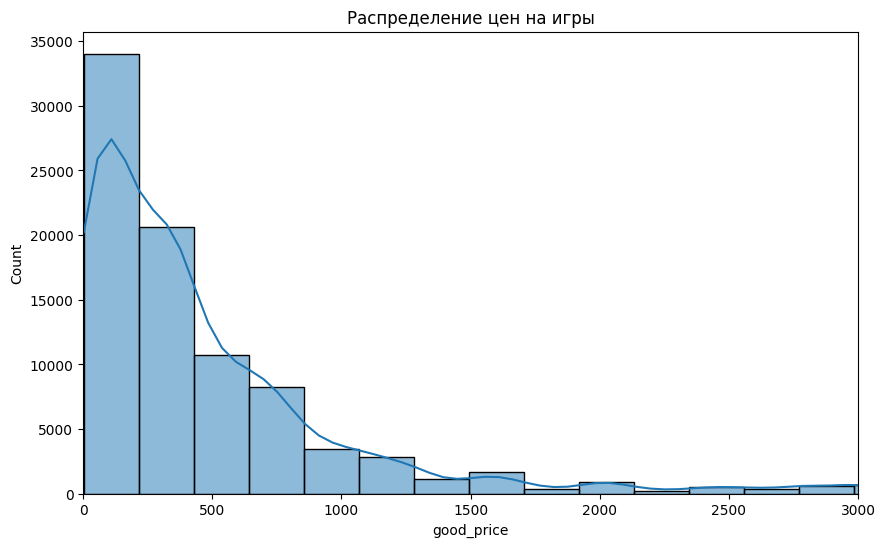

In [10]:
plt.figure(figsize=(10, 6))
snc.histplot(t_games['good_price'], bins=50, kde=True)
plt.xlim(0, 3000) 
plt.title('Распределение цен на игры')

Заметим, что число продаж заметно скачит в отдельных промежутках времени. Здесь, может быть несколько предположений, например, в конце декабря все покупают новогодние подарки, либо же выходит долгожданная игра.

Text(0.5, 1.0, 'Количество заказов по месяцам')

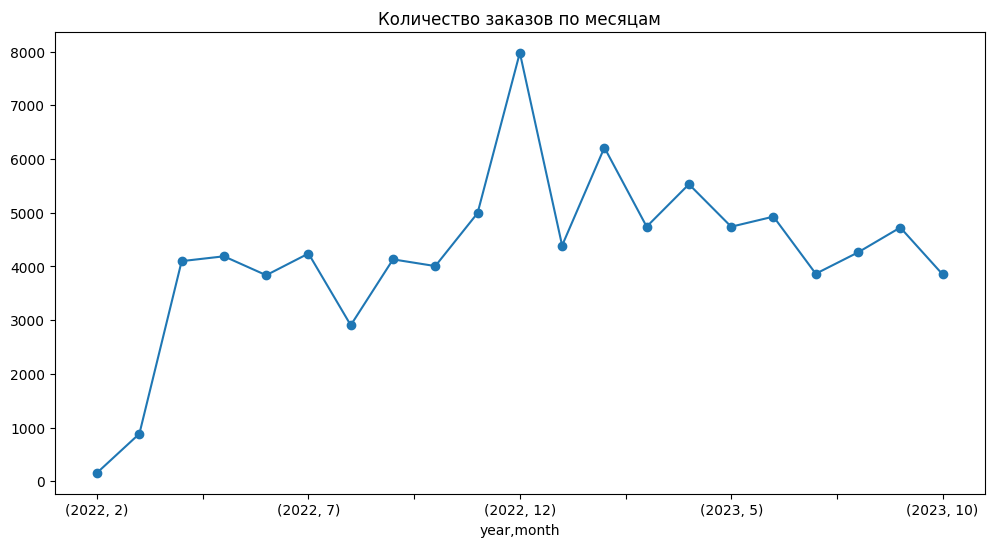

In [11]:
monthly_stats = t_games.groupby(['year', 'month'])['id'].nunique()
monthly_stats.plot(figsize=(12, 6), marker='o')
plt.title('Количество заказов по месяцам')

Для более удобного анализа в дальнейшем, создадим 2 вспомомгательные таблицы. Первая таблица с **характеристиками клиента(количество покупок, сумма всех покупок, самый популярный жанр для пользователя)**, вторая таблица с **характеристиками игры(ценой, общая сумма выручки, популярность в стиме)**

In [12]:
client_metrics = t_games.groupby('client_id').agg(
    total_orders=('id', 'nunique'),
    total_spend=('total_orders_sum', 'sum'),
    last_order=('order_day', 'max'),
    favorite_genre=('category_name', lambda x: x.mode()[0])
)

game_metrics = t_games.groupby('good_name').agg(
    median_price=('good_price', 'median'),
    total_sold=('good_cnt', 'sum'),
    popularity_rank=('steam_popularity_score', 'median'))

(0.0, 3000.0)

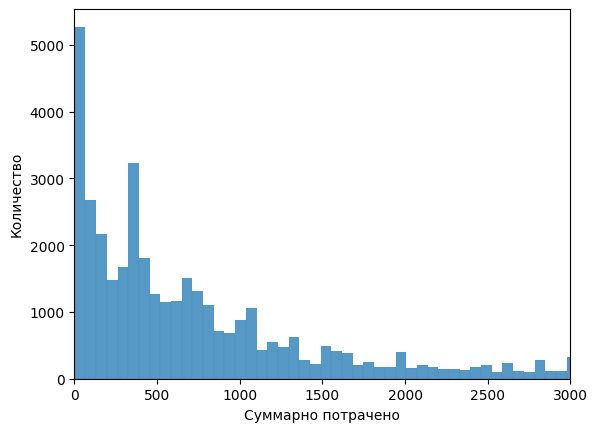

In [13]:
snc.histplot(client_metrics['total_spend'])
plt.xlabel('Суммарно потрачено')
plt.ylabel('Количество')
plt.xlim((0, 3000))

Дальше рассматривается **пол** клиентов, чтобы понять, кто чаще всего покупает, мужчина или женщина.

(array([0, 1]), [Text(0, 0, 'F'), Text(1, 0, 'M')])

<Figure size 1000x600 with 0 Axes>

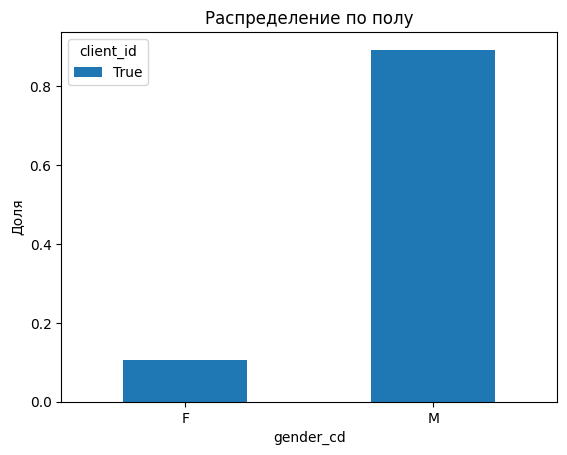

In [14]:
gender_dist = pd.crosstab(t_games['client_id'].isin(t_games['client_id'].unique()),
                        t_games['gender_cd'],
                        normalize='index')

plt.figure(figsize=(10, 6))
gender_dist.T.plot(kind='bar', stacked=True)
plt.title('Распределение по полу')
plt.ylabel('Доля')
plt.xticks(rotation=0)

Переходим к первой подзадаче, выделяем **геймеров** и сравниваем их с остальными пользователями, но для начала надо выснить, по каким признакам нужно их выделить. 

In [15]:
client_metrics['total_spend'].describe()

count     41284.000000
mean       1255.471930
std        2267.392347
min           2.320000
25%         199.000000
50%         576.695000
75%        1316.932500
max      117178.470000
Name: total_spend, dtype: float64

Как выяснилось, 75% клиентов совершили покупки меньше чем на 1316 рублей, следовательно мы можем предполагать, что оставшаяся часть,  являться геймерами, **но опять же, это не единственная характеристика, по которой мы можем их отличить от обычных клиентов**, также если они купили как минимум 3 игры.

In [16]:
gamers = client_metrics[
    (client_metrics['total_orders'] >= 3) & 
    (client_metrics['total_spend'] >= 1300)
].index
t_games['is_gamer'] = t_games['client_id'].isin(gamers)

others = t_games[~t_games['is_gamer']]['client_id'].unique()

Средний чек геймеров: 613 руб.
Средний чек остальных: 564 руб.


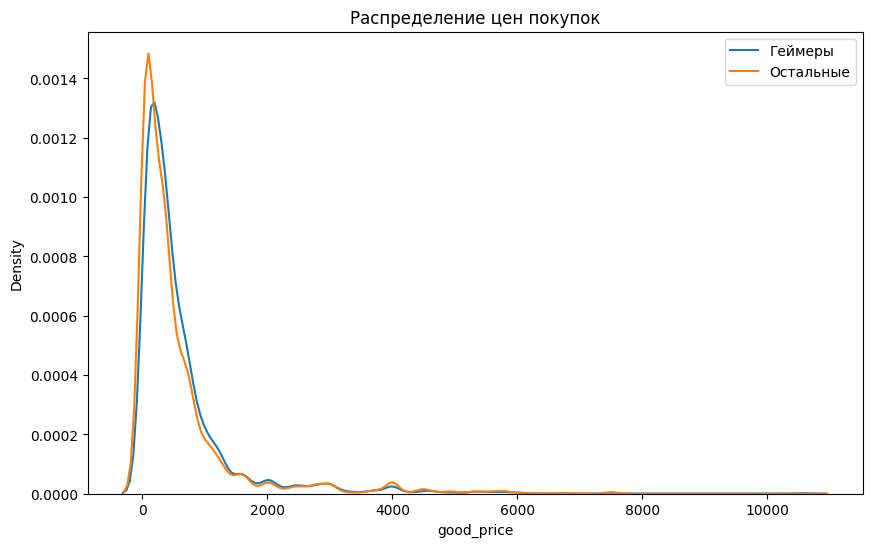

In [17]:
gamers = t_games[t_games['is_gamer']]
others = t_games[~t_games['is_gamer']]

print(f"Средний чек геймеров: {gamers['order_sum'].mean():.0f} руб.")
print(f"Средний чек остальных: {others['order_sum'].mean():.0f} руб.")
plt.figure(figsize=(10, 6))
snc.kdeplot(data=gamers, x='good_price', label='Геймеры')
snc.kdeplot(data=others, x='good_price', label='Остальные')
plt.title('Распределение цен покупок')
plt.legend()

Найдем средний интервал в днях между последовательными покупками. Визуализируем в виде графика и покажем как часто совершаются покупки геймеров и остальных клиентов. В данном случае, геймеры покупают реже.

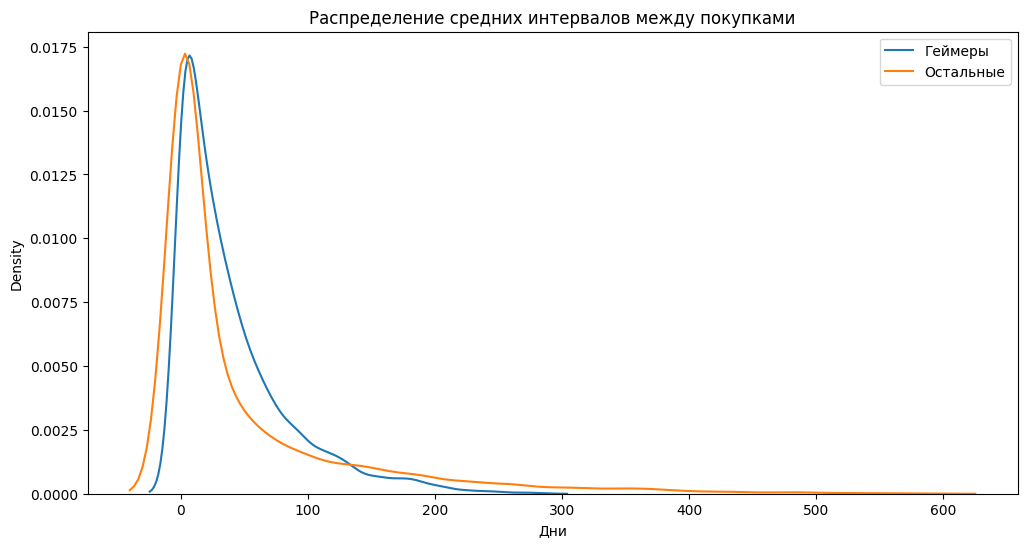

In [18]:
def get_intervals(group):
    diffs = group['order_day'].sort_values().diff().dt.days.dropna()
    return diffs.mean() if len(diffs) > 0 else np.nan 

intervals_gamers = t_games[t_games['is_gamer']].groupby('client_id').apply(get_intervals).dropna()
intervals_others = t_games[~t_games['is_gamer']].groupby('client_id').apply(get_intervals).dropna()

plt.figure(figsize=(12, 6))
snc.kdeplot(intervals_gamers.explode(), label="Геймеры")
snc.kdeplot(intervals_others.explode(), label="Остальные")
plt.title('Распределение средних интервалов между покупками')
plt.xlabel("Дни")
plt.legend()
plt.show()

Далее следует провести проверку, есть ли зависимоть между возрастом и тем, что пользователь *геймер*. Для этого мы смотрим на график, если будет такое предположение, то проведем статистический тест, чтобы удостовериться в том, что гипотеза оправдана.

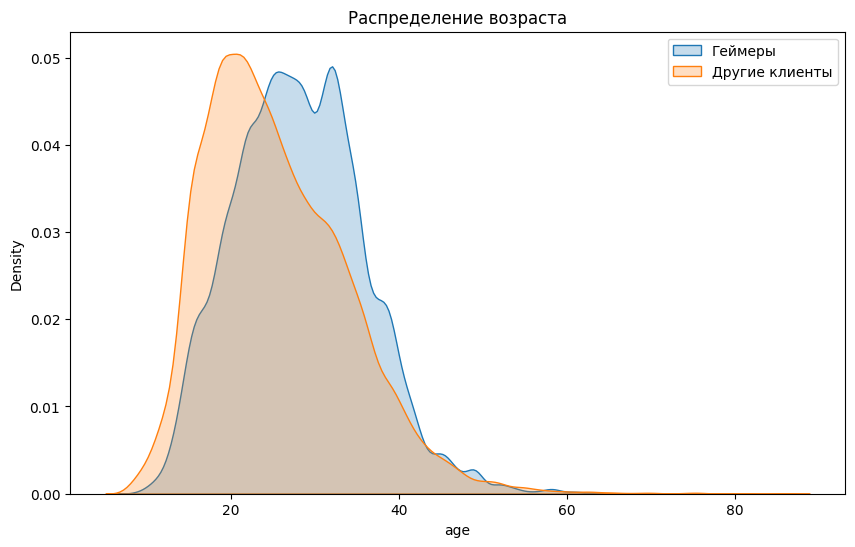

In [19]:
plt.figure(figsize=(10,6))
snc.kdeplot(data=gamers, x='age', label='Геймеры', fill=True)
snc.kdeplot(data=others, x='age', label='Другие клиенты', fill=True)
plt.title('Распределение возраста')
plt.legend()

После просмотра графика мы предполагаем, что в нем есть отклонения, поэтому имеет смысл проанализировать имеющиеся данные. Для этого, мы используем ожин из статистических тестов(**Манна Уитни**) или  t-тест, но поскольку тест Стьюдента работает только для нормальных распределений, проверим на эту *нормальность*.

In [20]:
from scipy import stats

gamers_age = t_games[t_games['is_gamer']]['age'].dropna()
others_age = t_games[~t_games['is_gamer']]['age'].dropna()

s, p_gamers = stats.normaltest(gamers_age)
s, p_others = stats.normaltest(others_age)

if p_gamers < 0.05 or p_others < 0.05:
    stat, p = stats.mannwhitneyu(gamers_age, others_age)
    test_name = "U-тест Манна-Уитни"
else:
    stat, p = stats.ttest_ind(gamers_age, others_age, equal_var=False)
    test_name = "t-тест"
print(f"Статистика = {stat:.3f}, p-value = {p:.5f}")
print(test_name)

Статистика = 1157782198.500, p-value = 0.00000
U-тест Манна-Уитни


По результатам получаем, что как минимум одно из распределений не является нормальным, так как не подходит под условие стандартного отклонения. Поэтому был проведен **U-тест**, который показал, что разница в возрасте *геймеров* и других пользователей существенная. Учтем в дальнейшем, это может пригодиться для формирования рекомендаций под конкретный возраст.

In [21]:
display(f'Средний возраст геймеров: {gamers_age.mean():.1f}, медиана: {gamers_age.median():.1f}')
display(f'Средний возраст остальных покупателей: {others_age.mean():.1f}, медиана: {others_age.median():.1f}')

'Средний возраст геймеров: 28.2, медиана: 28.0'

'Средний возраст остальных покупателей: 25.5, медиана: 24.0'

In [22]:
gender_stats = pd.crosstab(
    t_games['client_id'].isin(gamers['client_id']),
    t_games['gender_cd'],
    normalize='index'
)*100
gender_stats

gender_cd,F,M
client_id,,
False,11.299185,88.700815
True,9.787327,90.212673


Соотношение полов не так сильно меняется у заядлых игроков, поэтому не стоит его учитывать

Для дальнешего анализа пригодятся характеристики пользователя, а точнее его заработок и его траты на покупку игр.

In [23]:
finance_comparison = t_games.groupby(
    t_games['client_id'].isin(gamers['client_id'])
).agg({
    'monthly_income_amt': 'median',
    'order_sum': 'mean'
})
finance_comparison

,monthly_income_amt,order_sum
client_id,,
False,62000.0,564.478424
True,74000.0,612.927739


Из-за частых отклонений в доходах логичнее всего сравнить медиану, а не средний доход пользователей разных категорий. Уже на глаз видим, что доход заядлых игроков выше, чем у остальных пользователей. Вероятно, это говорит о том, что покупать игры готовы те, у кого хватает на них средств. Средняя сумма заказа у заядлых игроков выше, но этот факт мы ввели еще при разделении на заядлых игроков и остальных, поэтому из него не сделаем новых выводов.

In [24]:
t_games['games_share'] = t_games['order_sum'] / t_games['monthly_income_amt']
gamers_share = t_games.groupby(
    t_games['client_id'][t_games['is_gamer']]
)['games_share'].mean()
others_share = t_games.groupby(
    t_games['client_id'][~t_games['is_gamer']]
)['games_share'].mean()
display(f'Соотношение для геймеров: {gamers_share.mean():.5f} (среднее)')
display(f'Соотношение для остальных покупателей: {others_share.mean():.5f} (среднее)')

'Соотношение для геймеров: 0.00964 (среднее)'

'Соотношение для остальных покупателей: 0.01068 (среднее)'

Cоотношение почти одинаковое, значит обе категории готовы выделять одну часть от дохода на покупку игр

In [25]:
purchase_freq = pd.DataFrame({
    'Обычные покупатели': others.groupby('client_id')['id'].count().describe(),
    'Заядлые игроки': gamers.groupby('client_id')['id'].count().describe()
})
purchase_freq

,Обычные покупатели,Заядлые игроки
count,36178.000000,5106.000000
mean,1.438664,7.173717
std,1.181119,9.552217
min,1.000000,3.000000
25%,1.000000,3.000000
50%,1.000000,5.000000
75%,2.000000,8.000000
max,50.000000,279.000000


Смотрим на частотность покупок среди различных категорий. будем особенно отталкиваться от медианы, среднего и 75% персентиля. Все характеристики гораздо выше у заядлых игроков, поэтому однозначно следует вывод о том, что пользователям данной категории стоит предлагать игры снова (особенно тем, кто только вошел в данную категорию), так как для них покупка будет интересна

In [26]:
genre_com = pd.DataFrame({
    'Обычные покупатели': others['category_name'].value_counts().nlargest(5),
    'Заядлые игроки': gamers['category_name'].value_counts().nlargest(5)
})
genre_com

,Обычные покупатели,Заядлые игроки
category_name,,
Инди,6638.0,NaN
Приключения,6363.0,4717.0
Ролевые (RPG),NaN,3853.0
Симуляторы,NaN,3655.0
Скидки,4594.0,NaN
Стратегии,5053.0,5535.0
Экшн,10104.0,6905.0


Оценим самые популярные жанры, в каждой категории они свои, но особое внимание стоит уделить тем жанрам, которые популярны для одной категории, но не популярны для другой. Это говорит о том, для кого интересен данный жанр

Text(0, 0.5, 'Доля покупок')

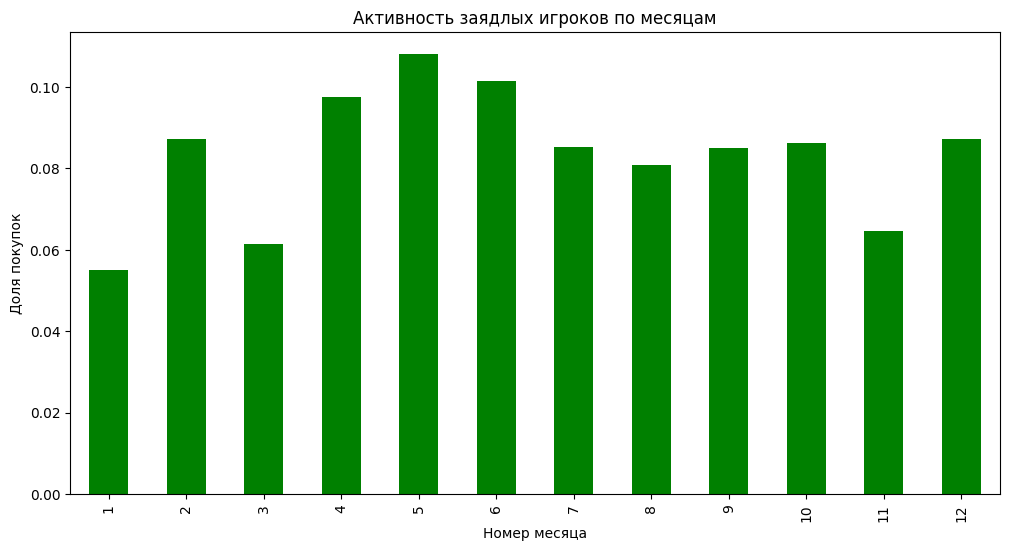

In [27]:
gamers['month'] = gamers['order_day'].dt.month
hourly_dist = gamers['month'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(12,6))
hourly_dist.plot(kind='bar', color='green')
plt.title('Активность заядлых игроков по месяцам')
plt.xlabel('Номер месяца')
plt.ylabel('Доля покупок')

Видим, что сезонное время для заядлых игроков - май, а меньше всего покупок в январе

In [28]:
price_bins = [0, 300, 1000, 3000, 10000]
price_labels = ['Бюджет', 'Стандарт', 'Премиум', 'Люкс']

t_games['price_segment'] = pd.cut(t_games['good_price'], bins=price_bins, labels=price_labels)
segment_dist = pd.crosstab(t_games['is_gamer'], t_games['price_segment'], normalize='index')

Проведем сегментацию товаров для будущего распределения на группы и рассмотрения не самого товара, а группу, в которой он находится

Text(0, 0.5, 'Доля покупок')

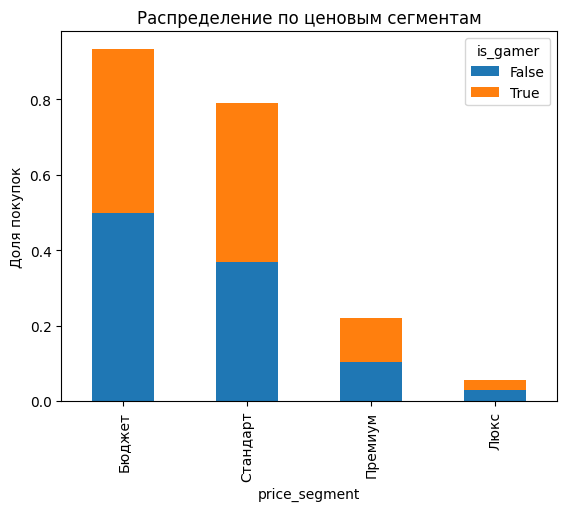

In [29]:
segment_dist.T.plot(kind='bar', stacked=True)
plt.title('Распределение по ценовым сегментам')
plt.ylabel('Доля покупок')

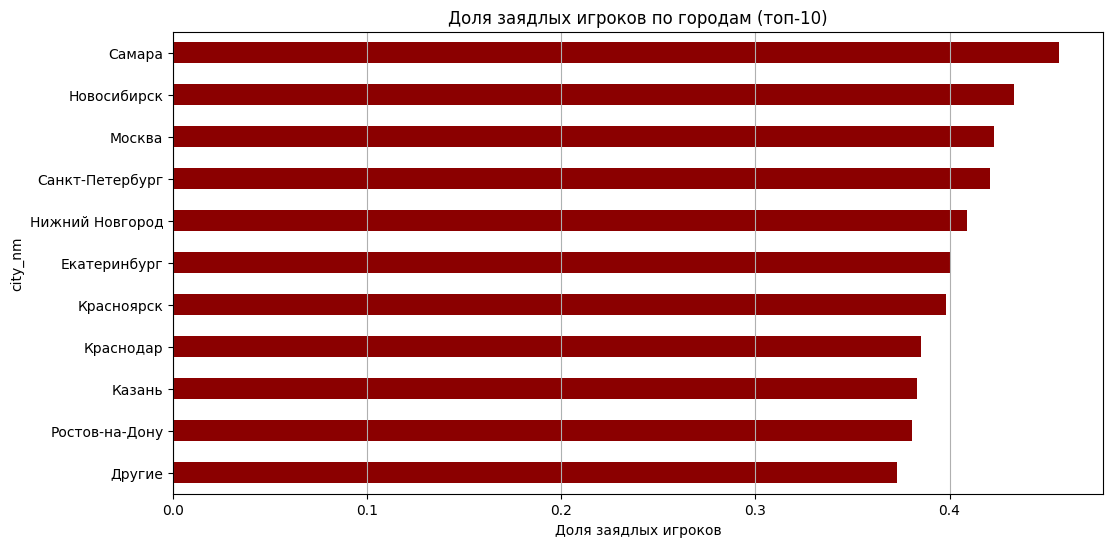

In [30]:
top_cities = t_games['city_nm'].value_counts().nlargest(10).index
city_dist = pd.crosstab(
    t_games['client_id'].isin(gamers['client_id'].tolist()),
    t_games['city_nm'].where(t_games['city_nm'].isin(top_cities), 'Другие'),
    normalize='columns'
)

plt.figure(figsize=(12,6))
city_dist.loc[True].sort_values().plot(kind='barh', color='darkred')
plt.title('Доля заядлых игроков по городам (топ-10)')
plt.xlabel('Доля заядлых игроков')
plt.grid(axis='x')

Города с наибольшей долей заядлых игроков можно рассмотривать как целевые для проведения очных мероприятий

Выводы по полученным данным: самые главные характеристики при выделении пользователей круга *"заядлые геймеры"* - это возраст, частотность покупок, месяц и города с наибольшей долей заядлых игроков. Ценовая сегментация покупаемых игр практически не отличается, как и соотношение полов. **При этом доход заядлых геймеров выше**, значит, чаще всего к данной аудитории относятся люди, способные позволить покупки и выделить средства, хотя при этом соотношение выделенных средств не отличается.

Нацелены ли игры на разные аудитории? То есть, можно ли выделить несколько групп игр, покупатели которых сильно отличаются друг от друга?
Для анализа разобьем игры на сегменты по объективным характеристикам: ценовой уровень, популярность, жанр
В каждом сегменте сравним аудиторию. В качестве метрик возьмем частоту покупок, размер среднего чека, временные интервалы и частоту покупок

возьмем уже готовое разбиение на ценовые категории

In [31]:
t_games['price_segment'].head(3)

0    Бюджет
1    Бюджет
2    Бюджет
Name: price_segment, dtype: category
Categories (4, object): ['Бюджет' < 'Стандарт' < 'Премиум' < 'Люкс']

In [32]:
popularity_groups = [
    (0, 100),
    (100, 1000),
    (1000, 3000),
    (3000, 5000)
]

t_games['pop_group'] = pd.cut(
    t_games['steam_popularity_score'],
    bins=[x[0] for x in popularity_groups] + [5000],
    labels=['Топ', 'Популярные', 'Средние', 'Узконаправленные'],
    right=False
)

Здесь мы разделяем игры на группы по их популярности в Steam.

In [33]:
price_dist = t_games.groupby(by='price_segment').agg(
    count=('id', 'count'),
    avg_price=('good_price', 'mean'),
    share=('id', lambda x: x.count()/len(t_games)) 
)
price_dist

,count,avg_price,share
price_segment,,,
Бюджет,41865,121.176311,0.472107
Стандарт,34599,548.872890,0.390169
Премиум,9706,1689.994314,0.109453
Люкс,2486,4482.737458,0.028034


Анализируем распределение товаров по ценовым сегментам, чтобы понять сколько товаров в одном сегменте, какая средняя цена и доля товаров.

In [34]:
genre_price = pd.crosstab(
    t_games['price_segment'],
    t_games['category_name'],
    values=t_games['good_price'],
    aggfunc='count',
    normalize='index'
)

sorted_genres = genre_price.sum().sort_values(ascending=False).index
genre_price_sorted = genre_price[sorted_genres]

top_genre_price = genre_price_sorted.iloc[:, :8]
top_genre_price

category_name,Экшн,Ролевые (RPG),Приключения,Стратегии,Бестселлеры,Инди,Скидки,Симуляторы
price_segment,,,,,,,,
Бюджет,0.139854,0.087472,0.128938,0.137513,0.000621,0.165819,0.071516,0.107942
Стандарт,0.217203,0.082661,0.128125,0.106766,0.069713,0.080956,0.114281,0.088818
Премиум,0.279827,0.130538,0.101896,0.113950,0.098702,0.041933,0.068926,0.050278
Люкс,0.370475,0.225261,0.104586,0.012470,0.153660,0.000000,0.024940,0.011263


Проведем связь между ценовыми сегментами и их жанрами, чтобы выявить популярные категории в каждом сегменте

In [35]:
def sort_by_column(df):
    return df.sort_values(ascending=False)

genre_price_sorted_by_segment = genre_price.apply(sort_by_column, axis=1)

top_genres_by_segment = genre_price_sorted_by_segment
top_genres_by_segment

category_name,Anime,VR,Xbox подписка,Аркады,Бестселлеры,Гонки,Для детей,Другое,Инди,Казуальные игры,...,Приключения,Ролевые (RPG),Симуляторы,Скидки,Спорт,Стратегии,Файтинги,Хоррор,Шутеры,Экшн
price_segment,,,,,,,,,,,,,,,,,,,,,
Бюджет,0.008217,0.009650,0.000000,0.009602,0.000621,0.032127,0.001553,0.000167,0.165819,0.052311,...,0.128938,0.087472,0.107942,0.071516,0.004777,0.137513,0.006569,0.021187,0.010391,0.139854
Стандарт,0.004046,0.000867,0.002775,0.004567,0.069713,0.005463,0.001127,0.003931,0.080956,0.012486,...,0.128125,0.082661,0.088818,0.114281,0.003468,0.106766,0.009220,0.017342,0.040059,0.217203
Премиум,0.002576,0.000206,0.015557,0.000103,0.098702,0.004121,0.000206,0.019472,0.041933,0.000618,...,0.101896,0.130538,0.050278,0.068926,0.002885,0.113950,0.005151,0.014630,0.020503,0.279827
Люкс,0.000402,0.000000,0.014883,0.000402,0.153660,0.001609,0.000000,0.021722,0.000000,0.002414,...,0.104586,0.225261,0.011263,0.024940,0.002816,0.012470,0.016090,0.001609,0.004023,0.370475


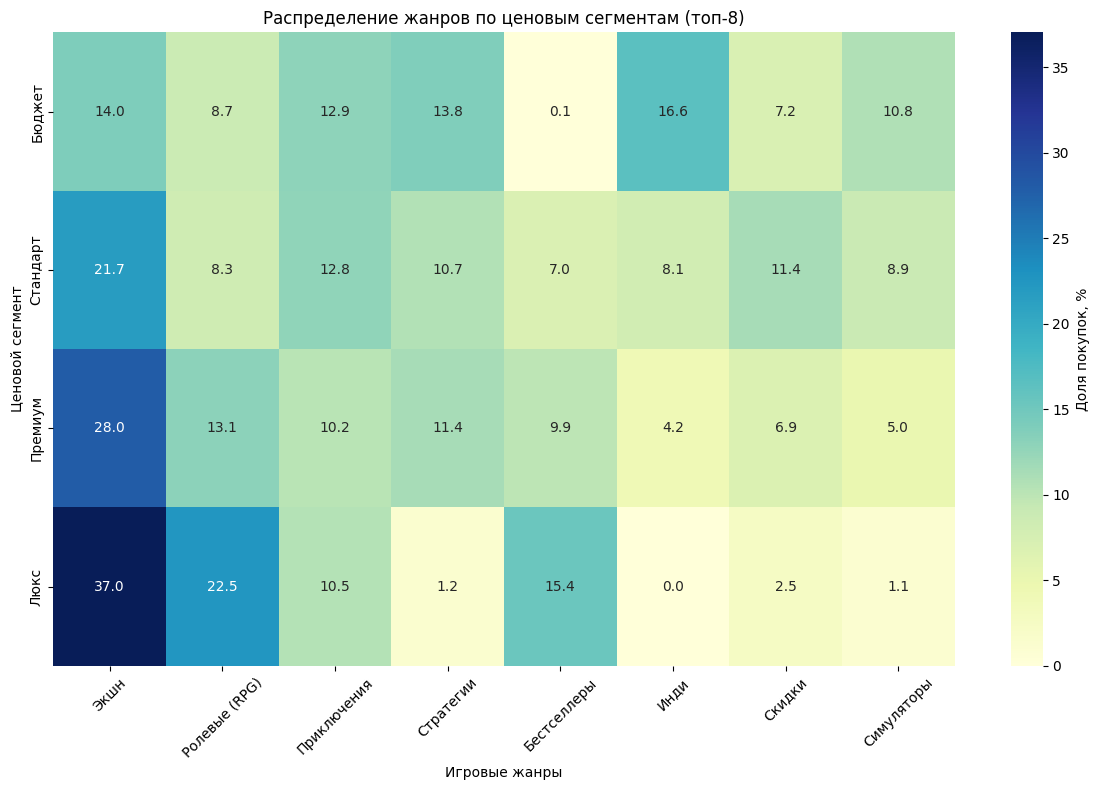

In [36]:
plt.figure(figsize=(12, 8))
snc.heatmap(top_genre_price*100, 
            annot=True, 
            fmt='.1f',
            cmap='YlGnBu',
            cbar_kws={'label': 'Доля покупок, %'})
plt.title('Распределение жанров по ценовым сегментам (топ-8)')
plt.xlabel('Игровые жанры')
plt.ylabel('Ценовой сегмент')
plt.xticks(rotation=45)
plt.tight_layout()

Видим, что среди самых популярных жанров самые дорогие игры среди покупаемых у **экшенов, RPG и бестселлеров**

Переходим к анализу сегментов, наченаем с анализы частотности для разных ценовых групп

In [37]:
purchase_period = t_games.groupby(['price_segment', 'client_id'])['id'].nunique().groupby('price_segment')
purchase_period.describe()['mean'].rename('Средняя частота покупок')


price_segment
Бюджет      1.014073
Стандарт    0.838073
Премиум     0.235103
Люкс        0.060217
Name: Средняя частота покупок, dtype: float64

Видим, что количество покупок конкретного пользователя среди бюджетных игр гораздо выше, чем у остальных. Но мы также учитывали и нулевые значения, понятно, что большинство покупают дешевые игры, из-за чего сильно занижается показатель остальных сегментов. учтем это

In [38]:
filtered = (
    t_games.groupby(['price_segment', 'client_id'])['id']
    .count()
    .reset_index()
    .query('id > 0')
).groupby('price_segment')
filtered.describe()['id']['mean']

price_segment
Бюджет      2.017688
Стандарт    1.638365
Премиум     1.306326
Люкс        1.144567
Name: mean, dtype: float64

Анализируем среднее количество покупок на одного клиента в каждом ценовом сегменте и видим, что все равно частота покупок у дешевых игр выше, чем у остальных. **Можно выдвигать предположение о том, что стоит предлагать другие дешевые игры пользователям, которые покупали игры из первых двух категорий, тогда есть вероятность, что они их также купят.**

In [39]:
genre_spend = t_games.groupby('category_name')['order_sum'].agg(['mean', 'median'])
genre_spend.sort_values('mean', ascending=False).head(10)

,mean,median
category_name,,
Карты оплаты,2549.205185,2834.93
Предзаказы,2421.066512,1999.00
Новинки,1812.761655,1499.00
Другое,1704.654041,1099.00
Xbox подписка,1590.283451,1099.00
Бестселлеры,1337.505286,680.00
Экшн,829.776161,440.00
Ролевые (RPG),815.232489,360.00
Файтинги,787.140921,350.44


Исследуем средние и медианные суммы заказов по жанрам игр, чтобы определить, какие жанры наиболее прибыльны.

In [40]:
genre_counter = t_games.groupby('category_name')['category_name'].agg(['count'])
genre_counter.sort_values(by='count', ascending=False).head(10)

,count
category_name,
Экшн,17009
Приключения,11080
Стратегии,10588
Инди,10150
Ролевые (RPG),8349
Симуляторы,8114
Скидки,7679
Бестселлеры,3782
Казуальные игры,2634


 Подсчет количества игр по жанрам и выводит топ-10 самых популярных жанров по числу игр.

Из предыдущих двух таблиц выделяются *особо премиальные жанры*. Например, экшн и ролевые игры покупаются часто и имеют высокую стоимость, поэтому их можно предлагать пользователям, которые готовы потратить определенную сумму на игры, тогда будет максимальная конвертация. А приключения, стратегии и инди игры стоит предлагать также и тем, кто никогда не покупал игры или покупал игры по низкой стоимости. Это значит, что они нравятся широкому кругу, при этом стоят не так много.

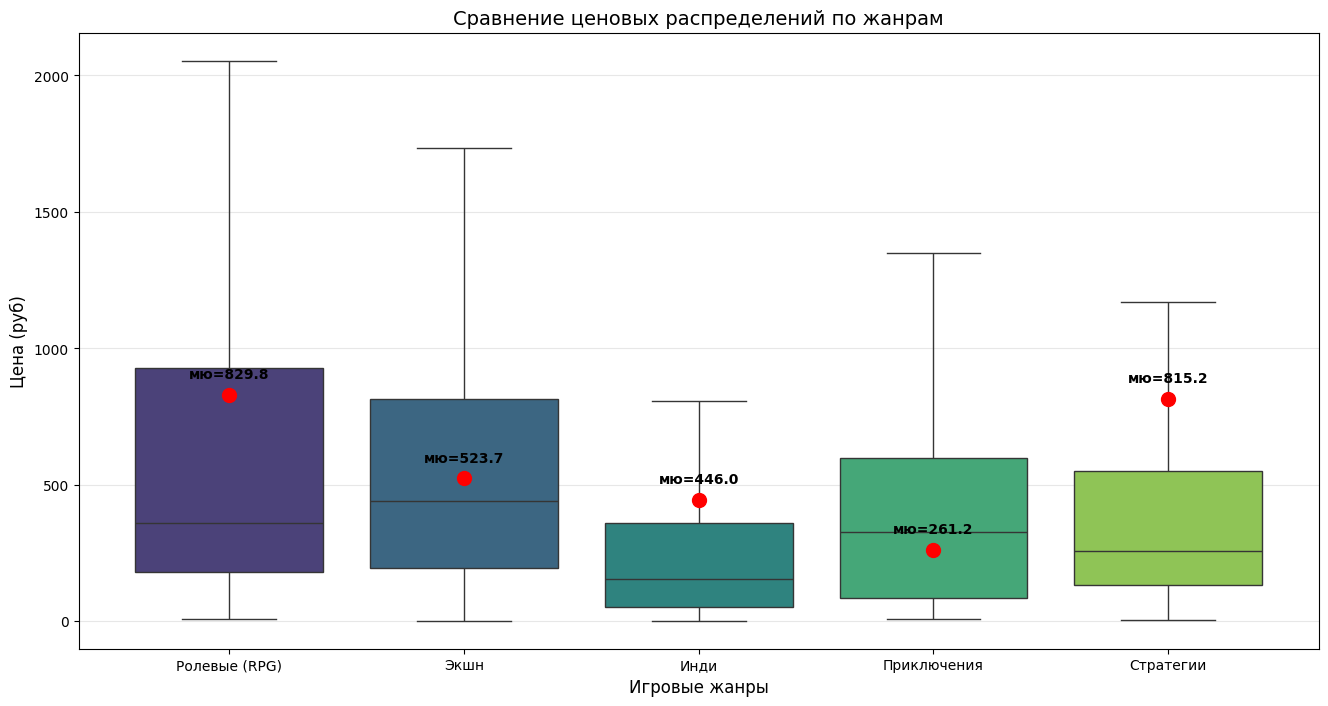

In [41]:
plt.figure(figsize=(16, 8))

top_genres = t_games['category_name'].value_counts().nlargest(5).index.tolist()
filtered = t_games[t_games['category_name'].isin(top_genres)]

snc.boxplot(data=filtered, 
        x='category_name', 
        y='good_price',
        palette='viridis',
        showfliers=False)

means = filtered.groupby('category_name')['good_price'].mean()
for i, genre in enumerate(top_genres):
        plt.scatter(i, means[genre], color='red', s=100, zorder=5)
        plt.text(i, means[genre]+60,
        f'мю={means[genre]:.1f}',
        ha='center',
        fontsize=10,
        fontweight='bold',
        )

plt.title('Сравнение ценовых распределений по жанрам', fontsize=14)
plt.xlabel('Игровые жанры', fontsize=12)
plt.ylabel('Цена (руб)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

Из графика заметно, что среди самых популярных жанров доминируют в цене ролевые и экшн игры, их медианное значение выше, чем у остальных. Значит, на категорию людей, покупающих игры не только низкого ценогого сегмента, можно продвигать именно эти жанры. Это подтверждает наши предыдущие выводы.

In [42]:
t_games.columns

Index(['id', 'client_id', 'order_day', 'category_id', 'category_name',
       'good_id', 'good_name', 'good_price', 'good_cnt', 'gender_cd', 'age',
       'education_level', 'city_nm', 'monthly_income_amt',
       'steam_popularity_score', 'order_sum', 'year', 'month', 'weekday',
       'total_orders_sum', 'is_gamer', 'games_share', 'price_segment',
       'pop_group'],
      dtype='object')

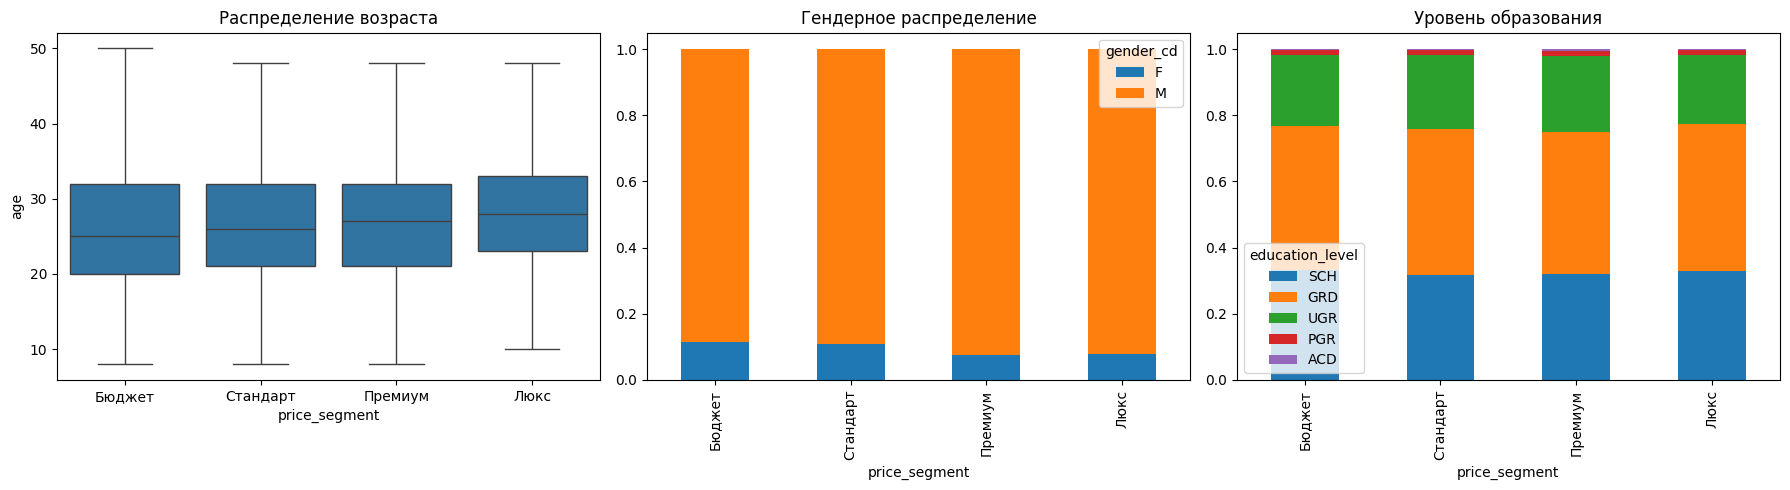

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

snc.boxplot(data=t_games, x='price_segment', y='age', ax=axes[0], showfliers=False)
axes[0].set_title('Распределение возраста')

gender_dist = pd.crosstab(t_games['price_segment'], t_games['gender_cd'], normalize='index')
gender_dist.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Гендерное распределение')

edu_order = ['SCH','GRD','UGR','PGR','ACD']
edu_dist = pd.crosstab(t_games['price_segment'], t_games['education_level'], normalize='index')[edu_order]
edu_dist.plot(kind='bar', stacked=True, ax=axes[2])
axes[2].set_title('Уровень образования')

plt.tight_layout()
plt.show()

Рассмотрим графики  по различным ценовым сегментам для отдельных групп. Самый большой разброс в возрасте у бюджетных игр, значит их покупают люди всех возрастов. Меньши всего разброс у самых дорогих игр, при этом медианное значение возраста у них выше всего (примерно 28 лет). В целом сильных отклонений в среднем для возраста нет, поэтому при проведении рекомендательной или скидочной кампании можно для всех ценовых сегментов концентрироваться на общем среднем возрасте покупателей. 
Вывод об общем доминировании покупок у мужской аудитории мы уже сделали ранее. а соотношение для разных категорий цен примерно одинаковое. 
Среди пользователей сервиса больше всего людей со средним, высшим и незаконченным высшим образованием - они и будут составлять ца, дальше рассмотрим, какие жанры доминируют для каждого уровня образования. Это поможет понять, что и кому логичнее предлагать

In [44]:
t_games['quarter'] = t_games['order_day'].dt.to_period('Q')

periods = {
    '2022 Q1-Q2': ('2022-01', '2022-06'),
    '2022 Q3-Q4': ('2022-07', '2022-12'),
    '2023 Q1-Q2': ('2023-01', '2023-06'), 
    '2023 Q3': ('2023-07', '2023-10')
}

In [45]:
city_stats = t_games.groupby('city_nm').agg({
    'client_id': 'nunique',
    'order_sum': 'sum', 
    'good_price': 'mean', 
    'age': 'median',
    'monthly_income_amt': 'median',
    'steam_popularity_score': 'median'
}).sort_values('order_sum', ascending=False).reset_index()

city_stats['revenue_share'] = city_stats['order_sum'] / city_stats['order_sum'].sum() * 100

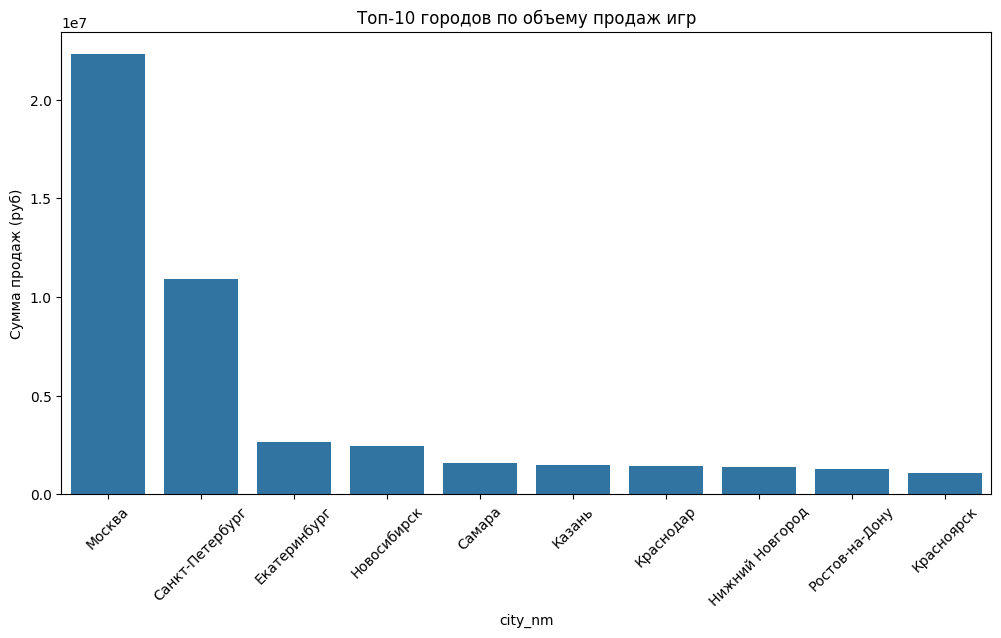

In [46]:
plt.figure(figsize=(12, 6))
snc.barplot(data=city_stats.head(10), x='city_nm', y='order_sum')
plt.title('Топ-10 городов по объему продаж игр')
plt.xticks(rotation=45)
plt.ylabel('Сумма продаж (руб)')
plt.show()

Выявляем топовые города по объему продаж. Очевидно, подтверждается то, что *Москва* и *Санкт-Петербург* приносят больше всего выручки, а из остальных городов доминируют города с высокой численностью населения.

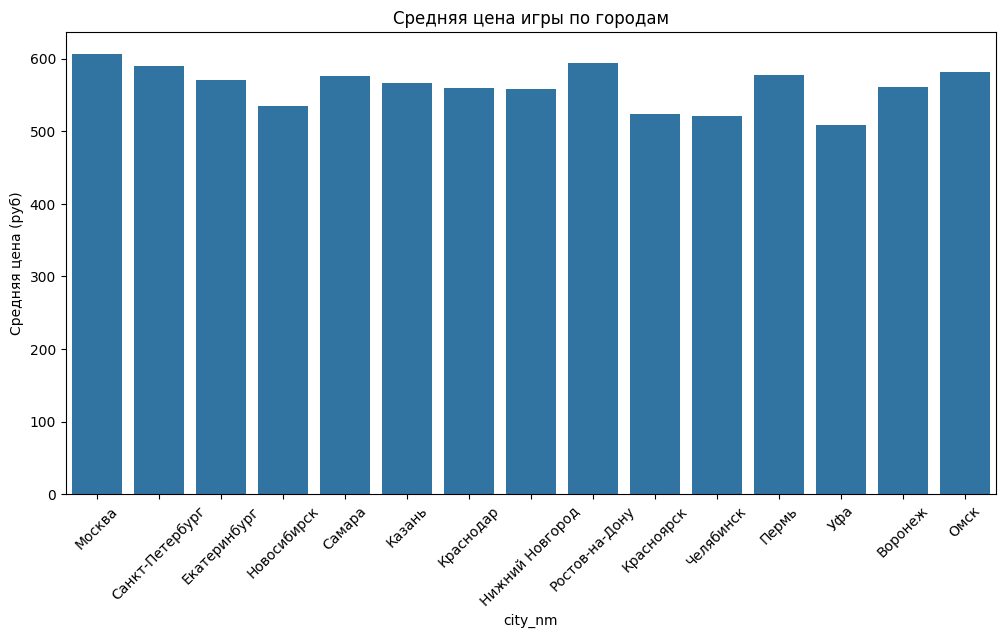

In [47]:
plt.figure(figsize=(12, 6))
snc.barplot(data=city_stats.head(15), x='city_nm', y='good_price')
plt.title('Средняя цена игры по городам')
plt.xticks(rotation=45)
plt.ylabel('Средняя цена (руб)')
plt.show()

Исходя из предыдущего графика, логичнее проверять средний чек продаж игр, он оказался приблизительно равным.

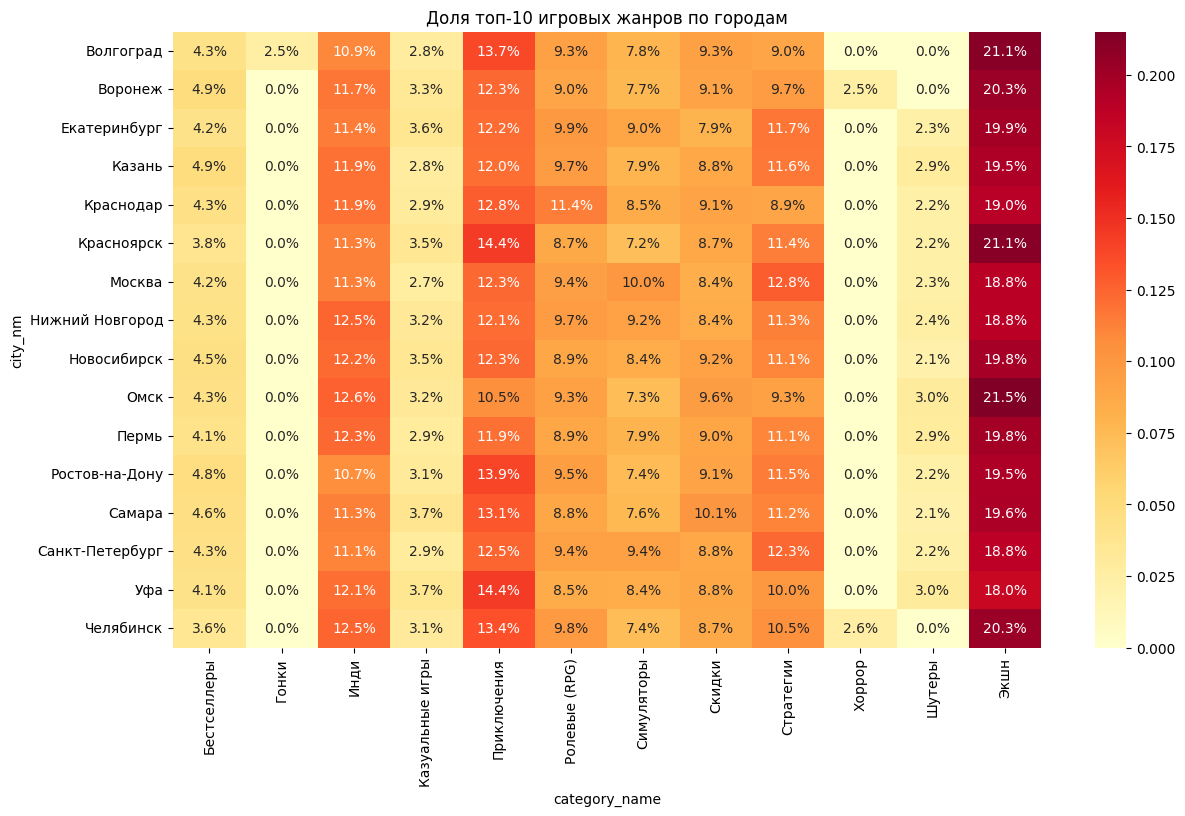

In [48]:
top_genres_by_city = t_games.groupby(['city_nm', 'category_name'])['good_id'].count()

total_by_city = t_games.groupby('city_nm')['good_id'].count()
top_genres_by_city = (top_genres_by_city / total_by_city).reset_index()

top_genres_by_city = top_genres_by_city.sort_values(['city_nm', 'good_id'], ascending=[True, False])\
                                    .groupby('city_nm').head(10)
heatmap = top_genres_by_city.pivot(index='city_nm', columns='category_name', values='good_id')

plt.figure(figsize=(14, 8))
snc.heatmap(heatmap.fillna(0), cmap='YlOrRd', annot=True, fmt='.1%')
plt.title('Доля топ-10 игровых жанров по городам')
plt.show()

Дальнейшей целью стояло выяснить, какие жанры наиболее популярны в разных городах. Чтобы объективно оценить, будем рассматривать оценивать не просто общее количество покупок, а отношение покупок конкретного жанра для заданного города. Из теплового графика можно взять выделяющиеся признаки, например, рпг для Краснодара или стратегии для Москвы и Санкт-Петербурга. Сразу можно оценить как общую популярность жанра, так и актуальность жанра в отдельных городах. Так, при выходе игры того или иного жанра, можно понять, в каких регионах ее больше оценят.